# California Housing — Week 4: House Price Prediction with Linear Regression
**Track:** Neurofive ML Track — Week 4
**Goal:** Predict a continuous number (house price) instead of a category, using Linear Regression.

Dataset: **California Housing** (the standard modern replacement for the deprecated Boston housing dataset), loaded directly from a public GitHub CSV mirror since it's the same data `sklearn.datasets` would otherwise fetch:
`https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv`

Each row is a California census block group; the target is `median_house_value`.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")


## 2. Load the dataset

In [2]:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 3. Handle missing values

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]


total_bedrooms    207
dtype: int64

In [5]:
# total_bedrooms has some missing values — fill with the median, since it's a
# right-skewed count column and median is robust to outlier block groups.
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum().sum()  # should be 0


np.int64(0)

## 4. Feature selection

I'm selecting 5 features I believe most affect house price:

- **`median_income`** — the single strongest predictor of neighborhood home value in this dataset (wealthier areas have pricier homes).
- **`total_rooms`** — a proxy for the overall size/density of housing in the block group.
- **`housing_median_age`** — older vs. newer housing stock affects price.
- **`total_bedrooms`** — related to home size and household capacity.
- **`population`** — density/demand proxy for the area.


In [6]:
selected_features = ['median_income', 'total_rooms', 'housing_median_age', 'total_bedrooms', 'population']

X = df[selected_features]
y = df['median_house_value']

X.describe()


,median_income,total_rooms,housing_median_age,total_bedrooms,population
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,2635.763081,28.639486,536.838857,1425.476744
std,1.899822,2181.615252,12.585558,419.391878,1132.462122
min,0.499900,2.000000,1.000000,1.000000,3.000000
25%,2.563400,1447.750000,18.000000,297.000000,787.000000
50%,3.534800,2127.000000,29.000000,435.000000,1166.000000
75%,4.743250,3148.000000,37.000000,643.250000,1725.000000
max,15.000100,39320.000000,52.000000,6445.000000,35682.000000


## 5. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (16512, 5)
Test shape: (4128, 5)


## 6. Train the Linear Regression model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coef_df = pd.DataFrame({'feature': selected_features, 'coefficient': model.coef_})
coef_df


,feature,coefficient
0,median_income,48690.194028
1,total_rooms,-20.807147
2,housing_median_age,1961.169503
3,total_bedrooms,198.652019
4,population,-26.830252


## 7. Evaluate: RMSE and R²

In [9]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R\u00b2 score: {r2:.4f}")


RMSE: 79,537.35
R² score: 0.5172


## 8. Predicted vs. Actual scatter plot

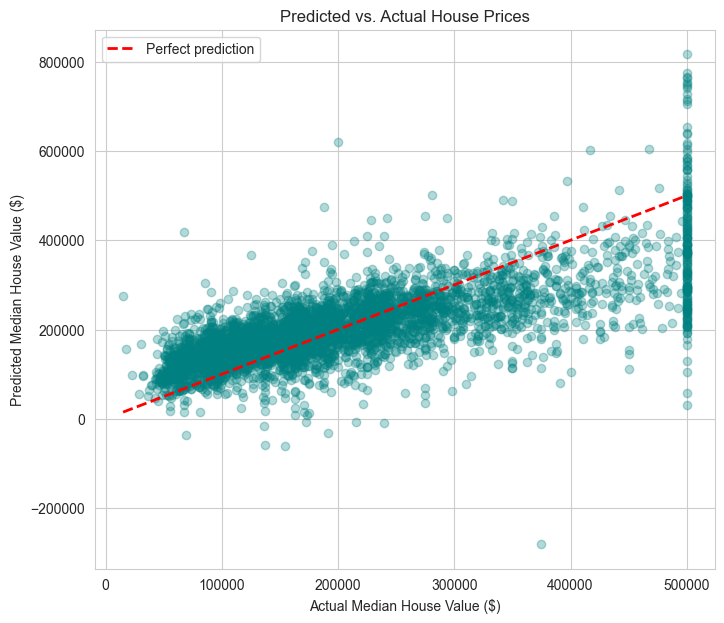

In [10]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Median House Value ($)')
plt.ylabel('Predicted Median House Value ($)')
plt.title('Predicted vs. Actual House Prices')
plt.legend()
plt.show()


**Reading the plot:** points sitting close to the red dashed line are cases where the model's prediction was close to the true price. The visible spread away from the line, especially at the high end (prices above ~$450k, which is close to this dataset's price cap), shows where the model struggles — a 5-feature Linear Regression is a simple baseline, not a precise valuation tool.

## 9. What does R² mean, in plain English?

R² measures how much of the variation in house prices my model actually explains, on a scale from 0 to 1. An R² of, say, 0.50 means that about half of the differences between cheap and expensive homes in this data can be explained by the five features I picked (income, room count, age, bedrooms, population) — the other half comes from things the model doesn't see at all, like exact location, school quality, or the condition of a specific house. It's not a percentage of "correct guesses," it's more like a report card on how well the model's story about *why* prices differ matches reality. A higher R² means the model's explanation fits the data better; a low R² means most of what drives price is still a mystery to this simple model, and a more advanced approach (more features, a non-linear model) would likely explain more of that variation.


## 10. Summary — Week 4

- Used the California Housing dataset (20,640 rows) as the modern standard replacement for the deprecated Boston housing dataset.
- Filled missing `total_bedrooms` values with the median.
- Selected 5 features (`median_income`, `total_rooms`, `housing_median_age`, `total_bedrooms`, `population`) as predictors of `median_house_value`.
- Trained a `LinearRegression` model on an 80/20 train/test split.
- Evaluated with RMSE and R² (see printed values above) and visualized fit quality with a predicted-vs-actual scatter plot.
- **Next step:** add `ocean_proximity` (one-hot encoded) and engineer `rooms_per_household` / `bedrooms_per_room` ratios, which typically improve this dataset's R² meaningfully over raw counts.
